## Comparing F1 score of all models for each batch_size

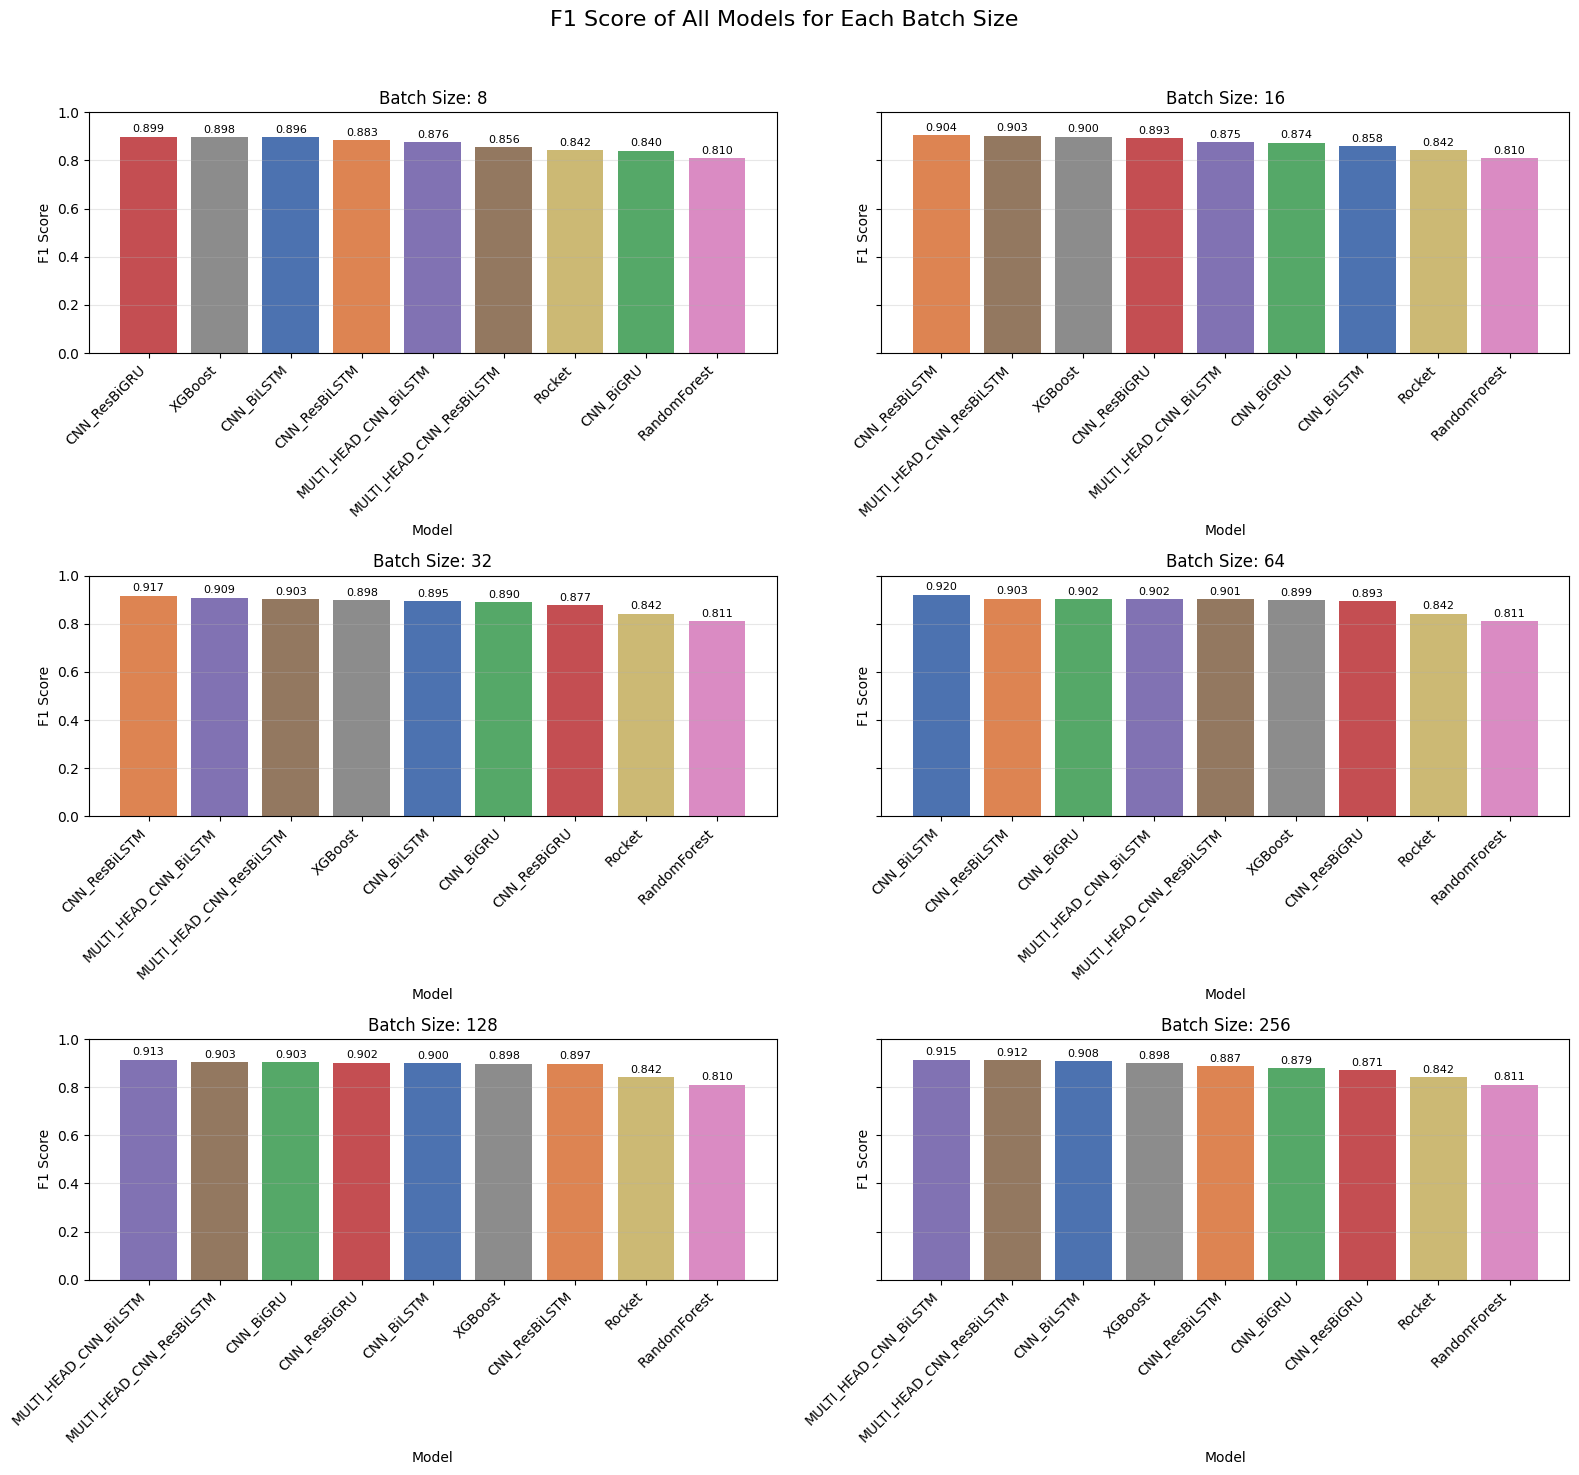

In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Find all batch size result directories
batch_sizes = [8, 16, 32, 64, 128, 256]
all_results = []

for bs in batch_sizes:
    dir_name = f"model_comparison_results_batch_size_{bs}"
    results_path = os.path.join(dir_name, "results.json")
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            data = json.load(f)
            for model_name, info in data.items():
                if 'metrics' in info and 'f1_score' in info['metrics']:
                    all_results.append({
                        'Batch_Size': bs,
                        'Model': model_name,
                        'F1_Score': info['metrics']['f1_score']
                    })

df = pd.DataFrame(all_results)

# Plotting: One subplot per batch size
fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharey=True)
axes = axes.flatten()

# We get unique models to ensure consistant color palette
model_order = df['Model'].unique().tolist()
palette = sns.color_palette('deep', len(model_order))
model_to_color = dict(zip(model_order, palette))

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    bs_data = df[df['Batch_Size'] == bs].sort_values('F1_Score', ascending=False)
    
    if len(bs_data) == 0:
        ax.set_visible(False)
        continue
        
    models_in_bs = bs_data['Model'].tolist()
    values = bs_data['F1_Score'].tolist()
    colors = [model_to_color[m] for m in models_in_bs]
    
    bars = ax.bar(models_in_bs, values, color=colors)
    ax.set_title(f'Batch Size: {bs}')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel('Model')
    ax.set_ylabel('F1 Score')
    ax.set_xticks(range(len(models_in_bs)))
    ax.set_xticklabels(models_in_bs, rotation=45, ha='right')
    
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, min(value + 0.01, 0.99), f'{value:.3f}', ha='center', va='bottom', fontsize=8)



fig.suptitle('F1 Score of All Models for Each Batch Size', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Make sure the directory exists (for example saving to batch size 64 folder or a general one)
os.makedirs('model_comparison_results_batch_size_64', exist_ok=True)
plt.savefig('model_comparison_results_batch_size_64/batch_comparison.png', dpi=180, bbox_inches='tight')

plt.show()

In [4]:
import json
import pandas as pd

# Load results for batch size 64
results_path = "model_comparison_results_batch_size_64/results.json"
metrics_data = []

# Parameters from the example table
parameters_map = {
    'CNN_BiLSTM': 295692,
    'MULTI_HEAD_CNN_ResBiLSTM': 601292,
    'XGBoost': 300,
    'MULTI_HEAD_CNN_BiLSTM': 608908,
    'CNN_BiGRU': 244492,
    'CNN_ResBiLSTM': 230668,
    'CNN_ResBiGRU': 195852,
    'Rocket': 1000,
    'RandomForest': 300
}

with open(results_path, 'r') as f:
    data = json.load(f)
    for model_name, info in data.items():
        if 'metrics' in info:
            m = info['metrics']
            metrics_data.append({
                'Model': model_name.replace('_', '\\_'),
                'Accuracy': m.get('accuracy', 0),
                'Precision': m.get('precision', 0),
                'Recall': m.get('recall', 0),
                'F1': m.get('f1_score', 0),
                'Parameters': parameters_map.get(model_name, 0)
            })

df_metrics = pd.DataFrame(metrics_data)
# Sort by F1 descending
df_metrics = df_metrics.sort_values(by='F1', ascending=False)

# Formatting functions
formatters = {
    'Accuracy': lambda x: f"{x:.4f}",
    'Precision': lambda x: f"{x:.4f}",
    'Recall': lambda x: f"{x:.4f}",
    'F1': lambda x: f"{x:.4f}",
    'Parameters': lambda x: f"{x}"
}

# Generate latex
latex_table = df_metrics.to_latex(
    index=False,
    formatters=formatters,
    column_format="lrrrrr",
    escape=False # Because we already escaped underscores manually
)

# Wrap in the requested table structure
latex_output = f"""\\begin{{table*}}[t]
\\centering
\\caption{{Model comparison metrics sorted by F1 for batch size 64.}}
\\label{{tab:model_comparison_batch_64}}
\\setlength{{\\tabcolsep}}{{5pt}}
{latex_table.strip()}
\\end{{table*}}
"""

print(latex_output)

\begin{table*}[t]
\centering
\caption{Model comparison metrics sorted by F1 for batch size 64.}
\label{tab:model_comparison_batch_64}
\setlength{\tabcolsep}{5pt}
\begin{tabular}{lrrrrr}
\toprule
Model & Accuracy & Precision & Recall & F1 & Parameters \\
\midrule
CNN\_BiLSTM & 0.9309 & 0.8969 & 0.9469 & 0.9203 & 295692 \\
CNN\_ResBiLSTM & 0.9138 & 0.8627 & 0.9524 & 0.9035 & 230668 \\
CNN\_BiGRU & 0.9100 & 0.8635 & 0.9535 & 0.9022 & 244492 \\
MULTI\_HEAD\_CNN\_BiLSTM & 0.9090 & 0.8757 & 0.9404 & 0.9020 & 608908 \\
MULTI\_HEAD\_CNN\_ResBiLSTM & 0.9146 & 0.8601 & 0.9519 & 0.9013 & 601292 \\
XGBoost & 0.9196 & 0.8975 & 0.9003 & 0.8986 & 300 \\
CNN\_ResBiGRU & 0.9072 & 0.8478 & 0.9491 & 0.8933 & 195852 \\
Rocket & 0.8886 & 0.9344 & 0.7869 & 0.8417 & 1000 \\
RandomForest & 0.7904 & 0.8038 & 0.8608 & 0.8110 & 300 \\
\bottomrule
\end{tabular}
\end{table*}

